# Calcul symbolique pour le système chariot-pendule

## Calcul symbolique

### Liste des symboles


In [1]:
import sympy as sp
from IPython.display import display, Math

x, phi, dx, dphi, d2x, d2phi, g, l, m, M, F = \
    sp.symbols('x, phi, x^(1}, phi^(1), x^(2), phi^(2), g, l, m, M, F')

### Equation du pendule

In [2]:
EQP = d2x*sp.cos(phi)+l*d2phi+g*sp.sin(phi)
display(Math(sp.latex(EQP)+' = 0'))

<IPython.core.display.Math object>

### Equation du chariot

In [3]:
EQC = -F + (m+M)*d2x+m*l*sp.cos(phi)*d2phi-m*l*sp.sin(phi)*dphi**2
display(Math(sp.latex(EQC)+' = 0'))

<IPython.core.display.Math object>

### Expression intermédiaire de $\phi^{(2)}$

In [4]:
D2PHIX = sp.solve(EQP, d2phi)[0]
display(Math('\\phi^{(2)} = '+sp.latex(D2PHIX)))

<IPython.core.display.Math object>

### Expression finale de $x^{(2)}$

In [5]:
D2X = sp.solve(EQC.subs(d2phi, D2PHIX), d2x)[0]
display(Math('x^{(2)} = '+sp.latex(D2X)))

<IPython.core.display.Math object>

### Expression finale de $\phi^{(2)}$

In [6]:
D2PHI = D2PHIX.subs(d2x, D2X).simplify()
display(Math('\\phi^{(2)} = '+sp.latex(D2PHI)))

<IPython.core.display.Math object>

### Bilan pour établir l'équation dynamique

In [7]:
display(Math('x^{(2)} = ' + sp.latex(D2X)))
display(Math('\\phi^{(2)} = ' + sp.latex(D2PHI)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Préparation pour les applications numériques

In [8]:
D2X_NUM = sp.lambdify([phi, dx, dphi, F, g, l, m, M], D2X, 'numpy')
D2PHI_NUM = sp.lambdify([phi, dx, dphi, F, g, l, m, M], D2PHI, 'numpy')

## Bilan des calculs symboliques

In [9]:
def calcul_symb():
    x, phi, dx, dphi, d2x, d2phi, g, l, m, M, F = \
        sp.symbols('x, phi, x^(1}, phi^(1), x^(2), phi^(2), g, l, m, M, F')
    EQP = d2x*sp.cos(phi)+l*d2phi+g*sp.sin(phi)
    EQC = -F + (m+M)*d2x+m*l*sp.cos(phi)*d2phi-m*l*sp.sin(phi) * dphi**2
    D2PHIX = sp.solve(EQP, d2phi)[0]
    D2X = sp.solve(EQC.subs(d2phi, D2PHIX), d2x)[0]
    D2PHI = D2PHIX.subs(d2x, D2X).simplify()
    D2X_F = sp.lambdify([phi, dx, dphi, F, g, l, m, M], D2X, 'numpy')
    D2PHI_F = sp.lambdify([phi, dx, dphi, F, g, l, m, M], D2PHI, 'numpy')

    return D2X_F, D2PHI_F

## Simulation numérique

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def calcul_nume(D2X_F, D2PHI_F):
    def equation_dyna(y, F, m, M, g, l):
        phi, dx, dphi = y[1], y[2], y[3]
        d2x = D2X_F(phi, dx, dphi, F, g, l, m, M)
        d2phi = D2PHI_F(phi, dx, dphi, F, g, l, m, M)
        return [dx, dphi, d2x, d2phi]

    def F(t):
        return 0

    M, m, l, g = 1, 0.1, 0.5, 9.81
    angleinit = 180.0-10.0
    x0, phi0, dx0, dphi0 = 0.0, angleinit*np.pi/180.0, 0.0, 0.0
    t_start, t_final = 0, 10
    y0 = [x0, phi0, dx0, dphi0]
    sol = solve_ivp(lambda t, y: equation_dyna(y, F(t), m, M, g, l),
                    [t_start, t_final], y0, rtol=1e-10, atol=1e-10)
    t = sol.t.T
    y = sol.y.T

    plt.figure()
    plt.plot(t, y[:, 0], label='$x_c$')
    plt.grid('on')
    plt.xlim(t_start, t_final)
    plt.xlabel('temps (en s)')
    plt.ylabel('position du chariot (en m)')
    plt.legend()

    plt.figure()
    plt.plot(t, 180.0*y[:, 1]/np.pi, label='$\\phi$')
    plt.grid('on')
    plt.xlim(t_start, t_final)
    plt.xlabel('temps (en s)')
    plt.ylabel('angle du pendule (en degré)')
    plt.legend()

    plt.show()

## Bilan final

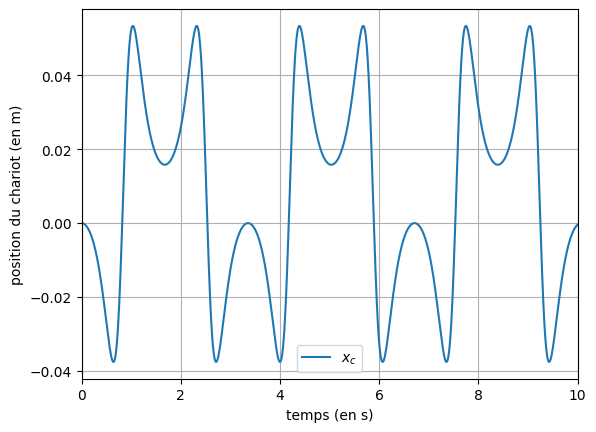

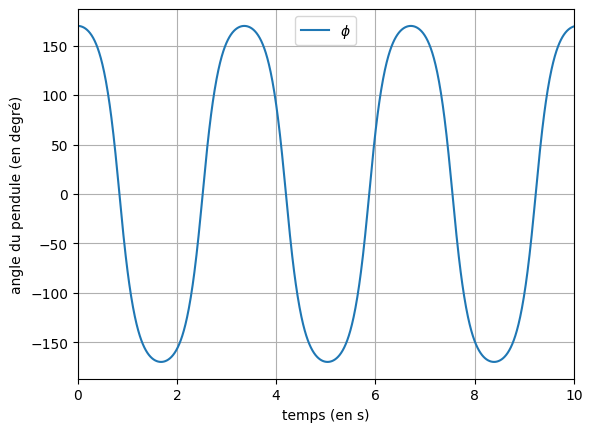

In [11]:
D2X_F, D2PHI_F = calcul_symb()
calcul_nume(D2X_F, D2PHI_F)